# Практика: Линейная регрессия

## Начальные итерации

0
Ошибка 5875.289219030679


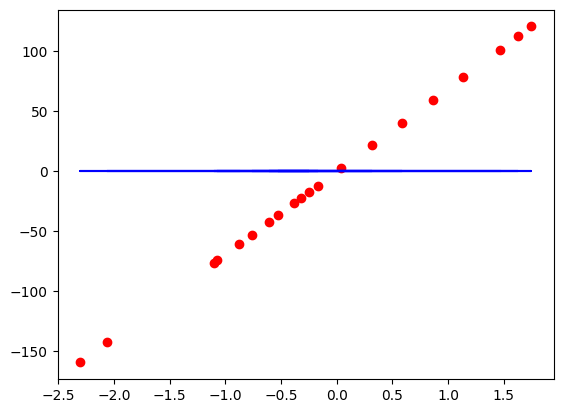

Ошибка 865.2442526807794


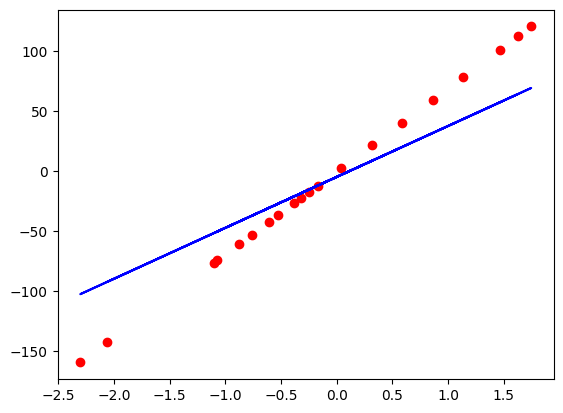

In [1]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

x = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/x.csv', index_col=0)['0']
y = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/y.csv', index_col=0)['0']

x.head()


class Model(object):
    def __init__(self):
        self.w0 = 0
        self.w1 = 0

    def predict(self, x):
        return self.w0 + self.w1 * x

    def error(self, X, Y):
        return ((self.predict(X) - Y) ** 2).mean()

    def fit(self, X, Y):
        alpha = 0.5
        df0 = ((self.predict(X) - Y)).mean()
        df1 = ((self.predict(X) - Y) * X).mean()
        self.w0 -= alpha * df0
        self.w1 -= alpha * df1

    def show(self, X, Y):
        plt.scatter(X, Y, c='r')
        plt.plot(X, self.predict(X), c='b')
        plt.show()

hyp = Model()
print(hyp.predict(10))
J = hyp.error(x, y)
print('Ошибка', J)
hyp.show(x, y)

hyp.fit(x, y)
J = hyp.error(x, y)
print('Ошибка', J)
hyp.show(x, y)



## Градиентный алгоритм

0 0
Ошибка 0.0001157248406210267


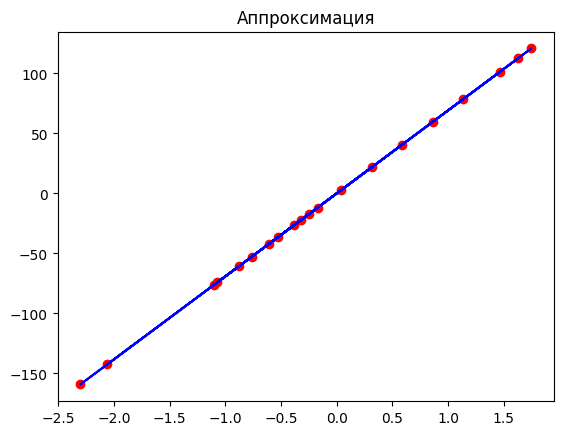

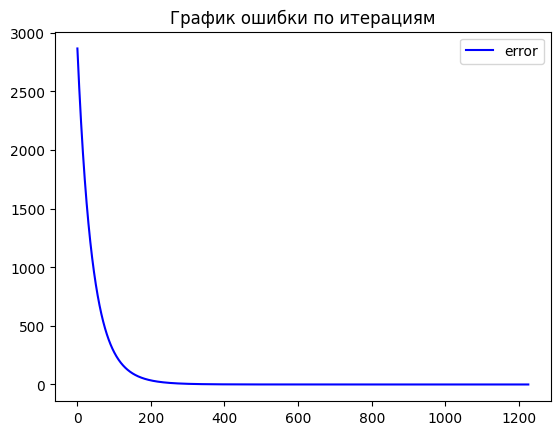

In [121]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

x = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/x.csv')
y = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/y.csv')

x.head()

class Model(object):
    def __init__(self):
        self.w0 = 0
        self.w1 = 0

    def add(self, a, b):
        self.w0 = a
        self.w1 = b

    def check(self, X):
        if isinstance(X, pd.Series):
            return X
        if isinstance(X, pd.DataFrame):
            return X['0']

    def predict(self, X):
        X = self.check(X)
        return self.w0 + self.w1 * X

    def error(self, X, Y):
        X = self.check(X)
        Y = self.check(Y)
        return (((self.predict(X) - Y) ** 2)/2).mean()

    def fit(self, X, Y, alpha=0.001, max_iter=10000, acc=0.000001):
        errors = []
        steps = []
        step = 0
        X = self.check(X)
        Y = self.check(Y)
        print(self.w0, self.w1)
        for i in range(max_iter):
            alpha = 0.01 / (1 + 0.001 * step)
            df0 = ((self.predict(X) - Y)).mean()
            df1 = ((self.predict(X) - Y) * X).mean()
            self.w0 -= alpha * df0
            self.w1 -= alpha * df1
            new_error = self.error(X, Y)
            errors.append(new_error)
            step += 1
            steps.append(step)
            if step != 1 and errors[-2] - new_error < acc:
                break
        return steps, errors

    def show(self, X, Y):
        X = self.check(X)
        Y = self.check(Y)
        plt.scatter(X, Y, c='r')
        plt.plot(X, self.predict(X), c='b')
        plt.title('Аппроксимация')
        plt.show()

hyp = Model()
steps, errors = hyp.fit(x, y)
J = hyp.error(x, y)
print('Ошибка', J)
hyp.show(x, y)

plt.plot(steps, errors, c='b', label='error')
plt.title('График ошибки по итерациям')
plt.legend()
plt.show()

## Изменения значений

-100 -200
Ошибка 1.6935131720315906
-10 -20
Ошибка 0.09423829059025625
10 20
Ошибка 0.009074561770103995
1000 2000
Ошибка 118.61331826201335


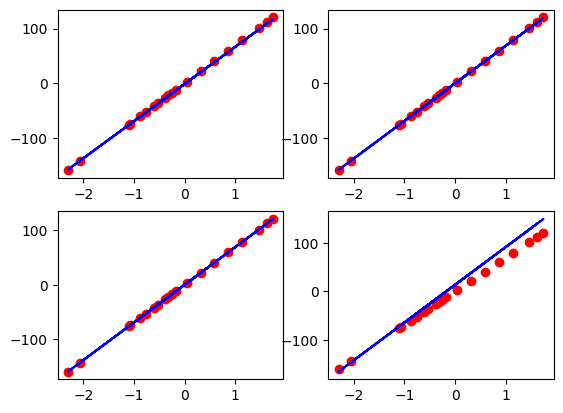

0 0
Ошибка 249.7663249484121


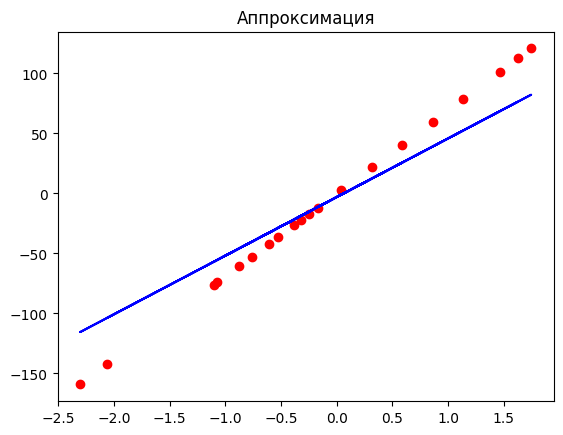

0 0
Ошибка 2930.3574755714026


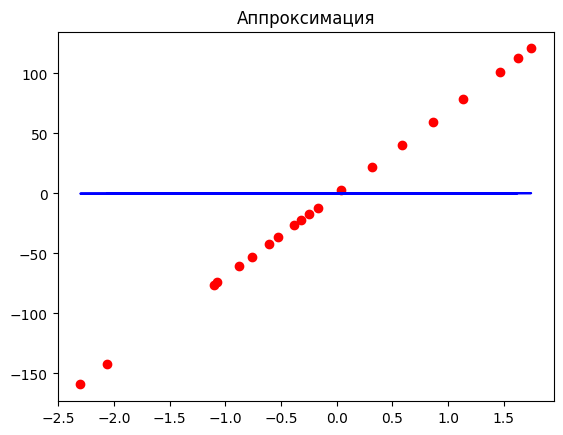

In [109]:
x = x['0']
y = y['0']

w = [(-100, -200), (-10, -20), (10, 20), (1000, 2000)]
fig, ax = plt.subplots(2, 2)
ax = ax.flatten()
for n, (w0, w1) in enumerate(w):
    hyp.add(w0, w1)
    steps, errors = hyp.fit(x, y)
    J = hyp.error(x, y)
    print('Ошибка', J)
    ax[n].scatter(x, y, c='r')
    ax[n].plot(x, hyp.predict(x), c='b')

plt.show()

hyp.add(0, 0)
steps, errors = hyp.fit(x, y, alpha=0.01, max_iter=100)
J = hyp.error(x, y)
print('Ошибка', J)
hyp.show(x, y)
hyp.add(0, 0)
steps, errors = hyp.fit(x, y, alpha=0.00001, max_iter=100)
J = hyp.error(x, y)
print('Ошибка', J)
hyp.show(x, y)